In [2]:
import pandas as pd
import numpy as np

customer_360 = pd.read_csv(
    "../data/processed/customer_360.csv"
)

customer_360.shape

(96096, 47)

In [3]:
customer_360.columns.tolist()

['customer_unique_id',
 'total_orders',
 'total_items',
 'total_spent',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'avg_order_value',
 'last_purchase_date',
 'recency_days',
 'first_purchase_date',
 'customer_lifetime_days',
 'active_months',
 'avg_review_score',
 'total_reviews',
 'has_review',
 'total_payment',
 'avg_payment_value',
 'total_payment_records',
 'max_installments',
 'credit_card_payments',
 'boleto_payments',
 'voucher_payments',
 'debit_card_payments',
 'avg_delivery_days',
 'max_delivery_days',
 'avg_delivery_delay',
 'late_orders',
 'on_time_orders',
 'purchase_frequency',
 'spend_per_item',
 'orders_per_seller',
 'products_per_order',
 'freight_cost_ratio',
 'payment_to_spent_ratio',
 'seller_diversity',
 'spend_per_order',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'customer_segment',
 'spend_score',
 'frequency_score',
 'customer_value_score',
 'cluster',
 'kmeans_segment']

In [4]:
customer_360["recency_days"].describe()

count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: recency_days, dtype: float64

In [5]:
customer_360["recency_days"].describe()

count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: recency_days, dtype: float64

In [6]:
customer_360["churn"] = (
    customer_360["recency_days"] >365
).astype(int)

In [7]:
customer_360["churn"].value_counts()

churn
0    67734
1    28362
Name: count, dtype: int64

In [8]:
customer_360["churn"].value_counts(normalize = True) * 100

churn
0    70.485764
1    29.514236
Name: proportion, dtype: float64

In [9]:
customer_360.to_csv(
    "../data/processed/customer_360_churn.csv",
    index=False
)

In [10]:
customer_360.shape

(96096, 48)

In [11]:
customer_360.columns.tolist()

['customer_unique_id',
 'total_orders',
 'total_items',
 'total_spent',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'avg_order_value',
 'last_purchase_date',
 'recency_days',
 'first_purchase_date',
 'customer_lifetime_days',
 'active_months',
 'avg_review_score',
 'total_reviews',
 'has_review',
 'total_payment',
 'avg_payment_value',
 'total_payment_records',
 'max_installments',
 'credit_card_payments',
 'boleto_payments',
 'voucher_payments',
 'debit_card_payments',
 'avg_delivery_days',
 'max_delivery_days',
 'avg_delivery_delay',
 'late_orders',
 'on_time_orders',
 'purchase_frequency',
 'spend_per_item',
 'orders_per_seller',
 'products_per_order',
 'freight_cost_ratio',
 'payment_to_spent_ratio',
 'seller_diversity',
 'spend_per_order',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'customer_segment',
 'spend_score',
 'frequency_score',
 'customer_value_score',
 'cluster',
 'kmeans_segment',
 'churn']

In [12]:
drop_cols = [
    "customer_unique_id",
    "churn",
    "last_purchase_date",
    "first_purchase_date"
]

In [13]:
drop_cols = [
    "customer_unique_id",
    "churn",
    "last_purchase_date",
    "first_purchase_date",
    "spend_score",
    "frequency_score",
    "customer_value_score",
    "cluster",
    "kmeans_segment"
]

X = customer_360.drop(columns=drop_cols)
y = customer_360["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96096, 39)
y shape: (96096,)


In [14]:
X.columns.tolist()

['total_orders',
 'total_items',
 'total_spent',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'avg_order_value',
 'recency_days',
 'customer_lifetime_days',
 'active_months',
 'avg_review_score',
 'total_reviews',
 'has_review',
 'total_payment',
 'avg_payment_value',
 'total_payment_records',
 'max_installments',
 'credit_card_payments',
 'boleto_payments',
 'voucher_payments',
 'debit_card_payments',
 'avg_delivery_days',
 'max_delivery_days',
 'avg_delivery_delay',
 'late_orders',
 'on_time_orders',
 'purchase_frequency',
 'spend_per_item',
 'orders_per_seller',
 'products_per_order',
 'freight_cost_ratio',
 'payment_to_spent_ratio',
 'seller_diversity',
 'spend_per_order',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'customer_segment']

In [15]:
drop_cols = [
    "customer_unique_id",
    "churn",
    "last_purchase_date",
    "first_purchase_date",

    # Segmentation / RFM features
    "spend_score",
    "frequency_score",
    "customer_value_score",
    "cluster",
    "kmeans_segment",
    "R_score",
    "F_score",
    "M_score",
    "RFM_score",
    "customer_segment"
]

X = customer_360.drop(columns=drop_cols)
y = customer_360["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96096, 34)
y shape: (96096,)


In [16]:
X = X.drop(columns = ["recency_days"])

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96096, 33)
y shape: (96096,)


In [18]:
# Train/Test Split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state  =42,
    stratify = y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (76876, 33)
X_test : (19220, 33)
y_train: (76876,)
y_test : (19220,)


In [19]:
print(X_train.dtypes)

total_orders                int64
total_items               float64
total_spent               float64
total_freight             float64
unique_products           float64
unique_sellers            float64
avg_order_value           float64
customer_lifetime_days      int64
active_months             float64
avg_review_score          float64
total_reviews               int64
has_review                  int64
total_payment             float64
avg_payment_value         float64
total_payment_records     float64
max_installments          float64
credit_card_payments      float64
boleto_payments           float64
voucher_payments          float64
debit_card_payments       float64
avg_delivery_days         float64
max_delivery_days         float64
avg_delivery_delay        float64
late_orders                 int64
on_time_orders              int64
purchase_frequency        float64
spend_per_item            float64
orders_per_seller         float64
products_per_order        float64
freight_cost_r

In [20]:
print("Missing values:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Missing values:
avg_review_score       547
avg_payment_value        1
max_installments         2
avg_delivery_days     2213
max_delivery_days     2213
avg_delivery_delay    2213
dtype: int64


In [21]:
X_train = X_train.drop(columns = ["on_time_orders"])
X_test = X_test.drop(columns = ["on_time_orders"])

In [22]:
from sklearn.impute  import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
])

In [24]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [25]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (76876, 32)
X_test_scaled : (19220, 32)


In [26]:
import numpy as np

print("Maximum absolute value:",
      np.max(np.abs(X_train_scaled)))

print("Anu Nan:",
       np.isnan(X_train_scaled).any())  

print("Any Inf:",
      np.isinf(X_train_scaled).any()) 

Maximum absolute value: 13664.08
Anu Nan: False
Any Inf: False


In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    solver = "liblinear",
    max_iter = 1000
)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [28]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [29]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test,y_pred))

Accuracy: 0.7071800208116545
Precision: 0.6130653266331658
Recall: 0.021505376344086023
F1 Score 0.04155313351498638
ROC-AUC 0.5079107305430476


In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.99      0.83     13547
           1       0.61      0.02      0.04      5673

    accuracy                           0.71     19220
   macro avg       0.66      0.51      0.43     19220
weighted avg       0.68      0.71      0.60     19220



In [31]:
import pandas as pd

orders = pd.read_csv(
    "../data/raw/olist_orders_dataset.csv"
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [32]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_purchase_timestamp"].min(), \
orders["order_purchase_timestamp"].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [33]:
cutoff_date = pd.Timestamp("2017-10-01")

prediction_end = cutoff_date + pd.Timedelta(days = 365)

print("Cutoff date:", cutoff_date)
print("Prediction period ends:", prediction_end)

Cutoff date: 2017-10-01 00:00:00
Prediction period ends: 2018-10-01 00:00:00


In [34]:
observation_orders = orders[
    orders["order_purchase_timestamp"] < cutoff_date

    ].copy()

print("Observation orders:", observation_orders.shape)


Observation orders: (27582, 8)


In [35]:
print(
    observation_orders["order_purchase_timestamp"].min(),
    observation_orders["order_purchase_timestamp"].max()
)

2016-09-04 21:15:19 2017-09-30 23:59:15


In [36]:
# Create the future orders

future_orders = orders[
    (orders["order_purchase_timestamp"] >= cutoff_date) &
    (orders["order_purchase_timestamp"]< prediction_end)
].copy()

print("Future orders:", future_orders.shape)

Future orders: (71855, 8)


In [37]:
print(
    future_orders["order_purchase_timestamp"].min(),
    future_orders["order_purchase_timestamp"].max()
)

2017-10-01 00:03:33 2018-09-29 09:13:03


In [38]:
future_customers = set(
    future_orders["customer_id"].unique()
)

print("Customers who purchased again:", len(future_customers))

Customers who purchased again: 71855


In [39]:
observation_customers = observation_orders["customer_id"].unique()

churn_data = pd.DataFrame({
    "Customer_id": observation_customers
})

churn_data["churn"] = (
    ~churn_data["Customer_id"].isin(future_customers)
).astype(int)

churn_data["churn"].value_counts()



churn
1    27582
Name: count, dtype: int64

In [40]:
observation_customers_set = set(
    observation_orders["customer_id"].unique()
)

future_customer_set = set(
    future_orders["customer_id"].unique()
)

overlap = observation_customers_set.intersection(
    future_customer_set
)

print("observation_customers:",  len(observation_customers_set))

print("Future customers:", len(future_customer_set))
print("Customer appearing in both:",len(overlap))

observation_customers: 27582
Future customers: 71855
Customer appearing in both: 0


In [41]:
customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [42]:
customers[["customer_id", "customer_unique_id"]].head()

,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


In [43]:
observation_orders = observation_orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on ="customer_id",
    how = "left"
)

In [44]:
future_orders = future_orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on = "customer_id",
    how = "left"
)

In [45]:
print(type(observation_orders))
print(type(future_orders))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [46]:
observation_orders = orders[
    orders["order_purchase_timestamp"] < cutoff_date
].copy()

print(type(observation_orders))
print(observation_orders.shape)

<class 'pandas.DataFrame'>
(27582, 8)


In [47]:
observation_orders = observation_orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

print(observation_orders.shape)

(27582, 9)


In [48]:
print(future_orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id']


In [49]:
future_orders = future_orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [50]:
print("customer_unique_id" in future_orders.columns)

False


In [51]:
future_orders = future_orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

print(future_orders.shape)
print("customer_unique_id" in future_orders.columns)

(71855, 11)
True


In [52]:
observation_customers = set(
    observation_orders["customer_unique_id"].dropna().unique()
)

future_customers = set(
    future_orders["customer_unique_id"].dropna().unique()
)

overlap = observation_customers.intersection(future_customers)

print("Observation unique customers:", len(observation_customers))
print("Future unique customers:", len(future_customers))
print("Customers appearing in both:", len(overlap))

Observation unique customers: 26773
Future unique customers: 69961
Customers appearing in both: 639


In [53]:
# Create the correct churn target

churn_data = pd.DataFrame({
    "customer_unique_id": list(observation_customers)
})

churn_data["churn"] = (
    ~churn_data["customer_unique_id"].isin(future_customers)
).astype(int)

print(churn_data["churn"].value_counts())

print(churn_data["churn"].value_counts())




churn
1    26134
0      639
Name: count, dtype: int64
churn
1    26134
0      639
Name: count, dtype: int64


In [54]:
print(
    churn_data["churn"].value_counts(normalize = True) * 100
)

churn
1    97.613267
0     2.386733
Name: proportion, dtype: float64


In [55]:
# Use a 180-day prediction window

cutoff_date = pd.Timestamp("2018-04-01")

prediction_end = cutoff_date + pd.Timedelta(days = 180)

print("cutoff date:", cutoff_date)
print("Prediction period ends:", prediction_end)

cutoff date: 2018-04-01 00:00:00
Prediction period ends: 2018-09-28 00:00:00


In [56]:
observation_orders = orders[
    orders["order_purchase_timestamp"] < cutoff_date
].copy()

future_orders = orders[
    (orders["order_purchase_timestamp"] >= cutoff_date) &
    (orders["order_purchase_timestamp"] < prediction_end)
].copy()

print("Observation orders:", observation_orders.shape)
print("Future orders:", future_orders.shape)

Observation orders: (66638, 8)
Future orders: (32798, 8)


In [57]:
# Add the stable customer ID

customer_mapping = customers[
    ["customer_id", "customer_unique_id"]
].drop_duplicates()

observation_orders = observation_orders.merge(
    customer_mapping,
    on = "customer_id",
    how = "left"
)

future_orders = future_orders.merge(
    customer_mapping,
    on = "customer_id",
    how = "left"
)



In [58]:
customer_mapping

,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066
...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e


In [59]:
observation_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2
4,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73
...,...,...,...,...,...,...,...,...,...
66633,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a
66634,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660
66635,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30
66636,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c


In [60]:
# Calculate customer overlap

observation_customers = set(
    observation_orders["customer_unique_id"].dropna().unique()
)

future_customers = set(
    future_orders["customer_unique_id"].dropna().unique()
)

overlap = observation_customers.intersection(
    future_customers
)


print("Observation customers:", len(observation_customers))
print("Future customers:", len(future_customers))
print("Repeat customers:", len(overlap))



















Observation customers: 64475
Future customers: 32253
Repeat customers: 634


In [61]:
# Create the target from this design

customer_data = pd.DataFrame({
    "customer_unique_id": list(observation_customers)
})

churn_data["churn"] = (
    ~churn_data["customer_unique_id"].isin(future_customers)
).astype(int)

print(churn_data["churn"].value_counts())
print(churn_data["churn"].value_counts(normalize = True)* 100)


churn
1    26537
0      236
Name: count, dtype: int64
churn
1    99.118515
0     0.881485
Name: proportion, dtype: float64


In [62]:
print(customer_360["churn"].value_counts())
print(customer_360["churn"].value_counts(normalize=True) * 100)

churn
0    67734
1    28362
Name: count, dtype: int64
churn
0    70.485764
1    29.514236
Name: proportion, dtype: float64


In [63]:
# Create the ML dataset

df_churn = customer_360.copy()

y = df_churn["churn"]

In [64]:
X= df_churn.drop(
  columns = [
   "churn",
   "customer_unique_id",
   "recency_days"
  ]
 )

In [65]:
X

,total_orders,total_items,total_spent,total_freight,unique_products,unique_sellers,avg_order_value,last_purchase_date,first_purchase_date,customer_lifetime_days,...,R_score,F_score,M_score,RFM_score,customer_segment,spend_score,frequency_score,customer_value_score,cluster,kmeans_segment
0,1,1.0,141.90,12.00,1.0,1.0,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,0,...,4,1,4,9,Potential,0.010385,0.0,0.007269,0,One-Time Customers
1,1,1.0,27.19,8.29,1.0,1.0,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,0,...,4,1,1,6,Low Value,0.001990,0.0,0.001393,0,One-Time Customers
2,1,1.0,86.22,17.22,1.0,1.0,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,...,1,1,2,4,Low Value,0.006310,0.0,0.004417,0,One-Time Customers
3,1,1.0,43.62,17.63,1.0,1.0,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,0,...,2,1,1,4,Low Value,0.003192,0.0,0.002235,0,One-Time Customers
4,1,1.0,196.89,16.89,1.0,1.0,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,0,...,2,1,4,7,Potential,0.014409,0.0,0.010087,0,One-Time Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,1,2.0,2067.42,497.42,2.0,1.0,2067.42,2017-06-08 21:00:36,2017-06-08 21:00:36,0,...,1,5,5,11,Loyal,0.151303,0.0,0.105912,0,One-Time Customers
96092,1,1.0,84.58,19.69,1.0,1.0,84.58,2017-12-10 20:07:56,2017-12-10 20:07:56,0,...,3,5,2,10,Loyal,0.006190,0.0,0.004333,0,One-Time Customers
96093,1,1.0,112.46,22.56,1.0,1.0,112.46,2017-02-07 15:49:16,2017-02-07 15:49:16,0,...,1,5,3,9,Potential,0.008230,0.0,0.005761,0,One-Time Customers
96094,1,1.0,133.69,18.69,1.0,1.0,133.69,2018-05-02 15:17:41,2018-05-02 15:17:41,0,...,4,5,4,13,High Value,0.009784,0.0,0.006849,0,One-Time Customers


In [66]:
X.shape

(96096, 45)

In [67]:
y.shape

(96096,)

In [68]:
X.columns.tolist()

['total_orders',
 'total_items',
 'total_spent',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'avg_order_value',
 'last_purchase_date',
 'first_purchase_date',
 'customer_lifetime_days',
 'active_months',
 'avg_review_score',
 'total_reviews',
 'has_review',
 'total_payment',
 'avg_payment_value',
 'total_payment_records',
 'max_installments',
 'credit_card_payments',
 'boleto_payments',
 'voucher_payments',
 'debit_card_payments',
 'avg_delivery_days',
 'max_delivery_days',
 'avg_delivery_delay',
 'late_orders',
 'on_time_orders',
 'purchase_frequency',
 'spend_per_item',
 'orders_per_seller',
 'products_per_order',
 'freight_cost_ratio',
 'payment_to_spent_ratio',
 'seller_diversity',
 'spend_per_order',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'customer_segment',
 'spend_score',
 'frequency_score',
 'customer_value_score',
 'cluster',
 'kmeans_segment']

In [69]:
columns_to_drop = [
    "last_purchase_date",
    "first_purchase_date",
    "spend_score",
    "frequency_score",
    "customer_value_score",
    "cluster",
    "kmeans_segment"
]

X = X.drop(columns=columns_to_drop, errors="ignore")

print("New X shape:", X.shape)
print(X.dtypes.value_counts())

New X shape: (96096, 38)
float64    27
int64      10
str         1
Name: count, dtype: int64


In [70]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96096, 38)
y shape: (96096,)


In [71]:
# train/test split

from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.20,
    random_state =42,
    stratify = y 
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (76876, 38)
X_test : (19220, 38)
y_train: (76876,)
y_test : (19220,)


In [72]:
# Handle missing values

print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

avg_review_score       547
avg_payment_value        1
max_installments         2
avg_delivery_days     2213
max_delivery_days     2213
avg_delivery_delay    2213
dtype: int64


In [73]:
print("Total missing values:", X_train.isnull().sum().sum())

Total missing values: 7189


In [74]:
# preprocessing pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])


In [75]:
X = X.drop(columns=["customer_segment"], errors="ignore")

print(X.select_dtypes(include=["object", "category"]).columns.tolist())

[]


In [76]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (76876, 37)
X_test : (19220, 37)


In [77]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

In [78]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (76876, 37)
X_test_scaled: (19220, 37)


In [79]:
# Train Logistic Regression baseline
from sklearn.linear_model import LinearRegression

log_model = LogisticRegression(
    random_state = 42,
    solver = "liblinear",
    max_iter = 1000
)

log_model.fit(X_train_scaled,y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [80]:
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [81]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
print("Predictions Completed")


Predictions Completed


In [82]:
# Evaluate the baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test,y_pred_log))
print("F1 score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test,y_prob_log))

Accuracy: 0.9149323621227887
Precision: 0.8610515021459227
Recall: 0.8487572712850344
F1 score: 0.8548601864181092
ROC-AUC: 0.9815386121173401


In [83]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     13547
           1       0.86      0.85      0.85      5673

    accuracy                           0.91     19220
   macro avg       0.90      0.90      0.90     19220
weighted avg       0.91      0.91      0.91     19220



[[12770   777]
 [  858  4815]]


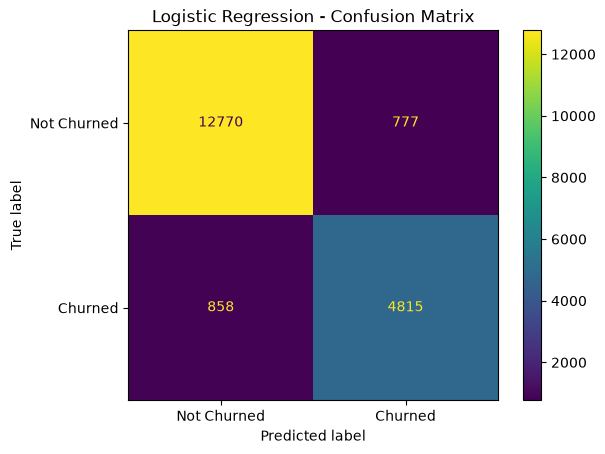

In [84]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["Not Churned", "Churned"]
).plot()
plt.title("Logistic Regression - Confusion Matrix" )
plt.show()



In [85]:
# Check feature coefficients

import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending =False
)

print(feature_importance.head(15))

                   Feature  Coefficient  Absolute_Coefficient
33                 R_score    -8.982951              8.982951
36               RFM_score    -3.106441              3.106441
34                 F_score     1.746086              1.746086
35                 M_score     1.743015              1.743015
2              total_spent     0.775233              0.775233
12           total_payment    -0.427514              0.427514
13       avg_payment_value    -0.298592              0.298592
22      avg_delivery_delay    -0.271698              0.271698
21       max_delivery_days    -0.213149              0.213149
5           unique_sellers     0.204324              0.204324
4          unique_products    -0.200923              0.200923
0             total_orders     0.150598              0.150598
30  payment_to_spent_ratio     0.125689              0.125689
8            active_months    -0.119235              0.119235
7   customer_lifetime_days    -0.119235              0.119235


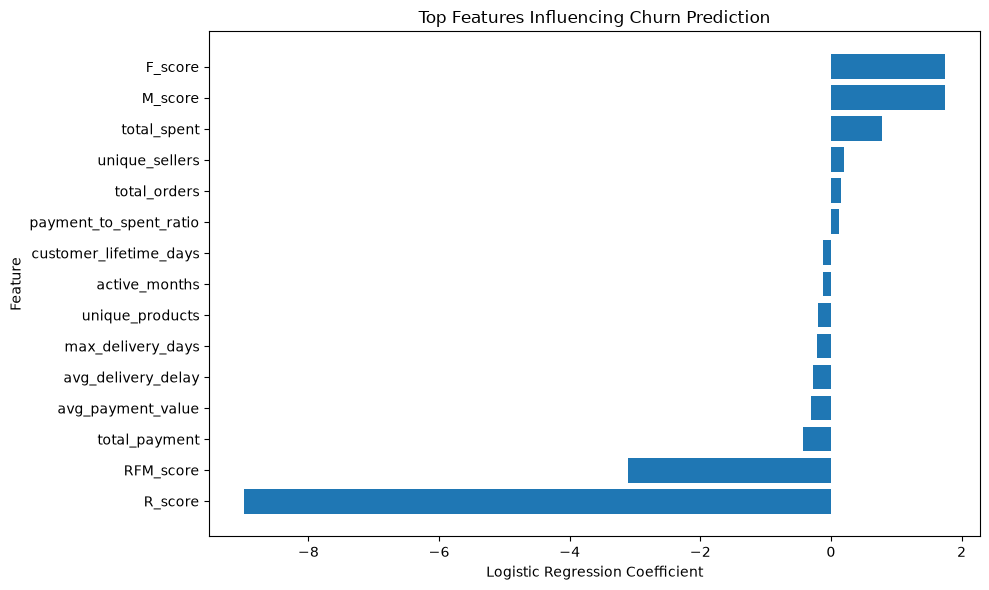

In [86]:
top_features = feature_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize = (10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Churn Prediction")

plt.tight_layout()
plt.show()

In [87]:
# Remove the leakage features
leakage_columns = [
    "R_score",
    "RFM_score"
]

X = X.drop(
    columns=leakage_columns,
    errors="ignore"
)

print("X shape:", X.shape)

X shape: (96096, 35)


In [88]:
# ecreate the split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (76876, 35)
X_test: (19220, 35)


In [89]:
# Recreate preprocessing

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)



In [90]:
# Train Logistic Regression again

log_model = LogisticRegression(
    random_state = 42,
    solver = "liblinear",
    max_iter = 1000
)

log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]




In [91]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))

Accuracy : 0.9149323621227887
Precision: 0.8610515021459227
Recall   : 0.8487572712850344
F1 Score : 0.8548601864181092
ROC-AUC  : 0.6176977577889154


In [92]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs = -1,
    class_weight = "balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest trained successfully")



Random Forest trained successfully


In [93]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7396982310093653
Precision: 0.5639801375095492
Recall   : 0.5205358716728362
F1 Score : 0.5413878448987075
ROC-AUC  : 0.7678153322775136


In [94]:
# Feature importance from Random Forest

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending = False
)

print(rf_importance.head(15))

                 Feature  Importance
3          total_freight    0.120534
22    avg_delivery_delay    0.114974
21     max_delivery_days    0.086751
20     avg_delivery_days    0.086277
29    freight_cost_ratio    0.080744
26        spend_per_item    0.062611
12         total_payment    0.061039
13     avg_payment_value    0.060553
2            total_spent    0.059881
6        avg_order_value    0.059363
32       spend_per_order    0.059089
33               F_score    0.033576
15      max_installments    0.030223
9       avg_review_score    0.025681
16  credit_card_payments    0.006933


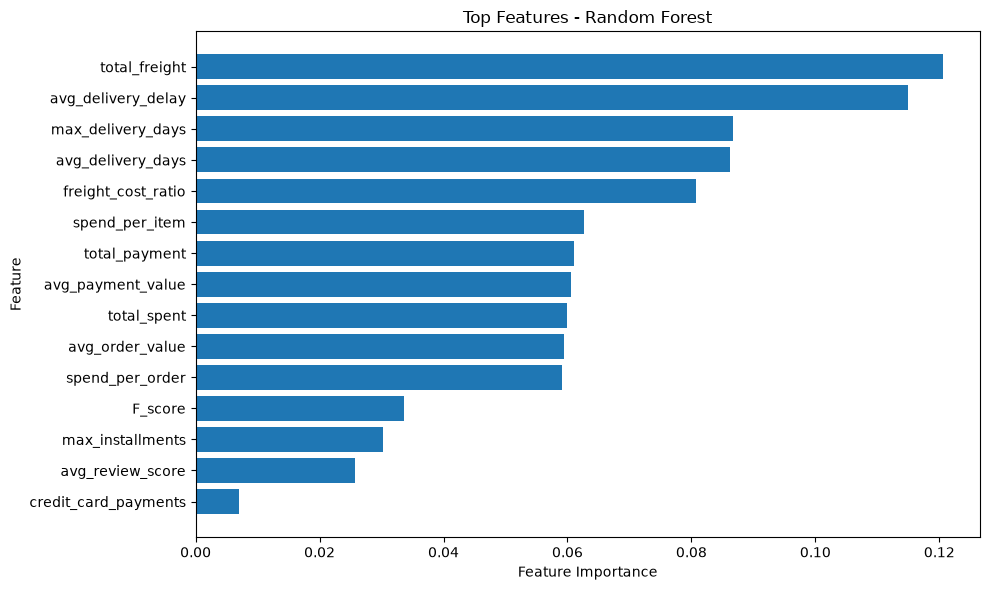

In [95]:
top_rf = rf_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features - Random Forest")

plt.tight_layout()
plt.show()

In [96]:
from sklearn.impute import SimpleImputer

imputer_gb = SimpleImputer(strategy="median")

X_train_gb = imputer_gb.fit_transform(X_train)
X_test_gb = imputer_gb.transform(X_test)

print("X_train_gb:", X_train_gb.shape)
print("X_test_gb :", X_test_gb.shape)

X_train_gb: (76876, 35)
X_test_gb : (19220, 35)


In [97]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_gb, y_train)

y_pred_gb = gb_model.predict(X_test_gb)
y_prob_gb = gb_model.predict_proba(X_test_gb)[:, 1]

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [98]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_gb))

Accuracy : 0.7234131113423518
Precision: 0.7297297297297297
Recall   : 0.09994711792702274
F1 Score : 0.1758139534883721
ROC-AUC  : 0.7263193261355368


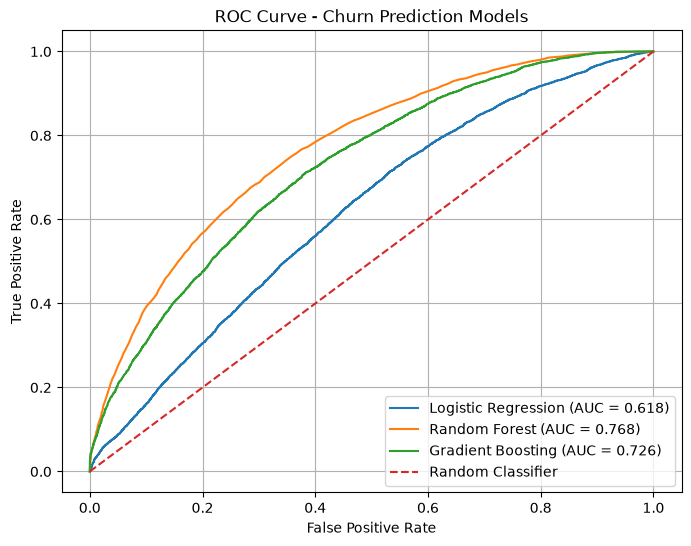

In [99]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc(fpr_log, tpr_log):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {auc(fpr_gb, tpr_gb):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction Models")
plt.legend()
plt.grid()
plt.show()

In [100]:
# Hyperparameter tuning for Random Forest

from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    random_state = 42,
    n_jobs = -1,
    class_weight = "balanced"
)

param_dist = {
    "n_estimators": [100,200,300],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2,5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]

}
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


In [101]:
rf_random.fit(X_train_gb, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whi

In [102]:
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}

Best CV ROC-AUC:
0.7575452527742085


In [103]:
best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("---------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_tuned))

c:\Users\sanju\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\sanju\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Tuned Random Forest Results
---------------------------
Accuracy : 0.7175338189386056
Precision: 0.5181493603094317
Recall   : 0.6139608672659969
F1 Score : 0.5620008067769262
ROC-AUC  : 0.7655987314131861


In [104]:
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79     13547
           1       0.52      0.61      0.56      5673

    accuracy                           0.72     19220
   macro avg       0.67      0.69      0.68     19220
weighted avg       0.73      0.72      0.72     19220



In [105]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    y_pred_threshold = (
        y_prob_rf_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.314421  0.997356  0.478114
1        0.15   0.325688  0.993654  0.490579
2        0.20   0.338250  0.982196  0.503206
3        0.25   0.356819  0.957871  0.519950
4        0.30   0.377369  0.919443  0.535112
5        0.35   0.404588  0.867442  0.551805
6        0.40   0.437027  0.804336  0.566340
7        0.45   0.476179  0.720606  0.573432
8        0.50   0.518149  0.613961  0.562001
9        0.55   0.570427  0.501851  0.533946
10       0.60   0.618048  0.383924  0.473633
11       0.65   0.671215  0.268817  0.383889
12       0.70   0.720430  0.165345  0.268961
13       0.75   0.786885  0.093072  0.166456
14       0.80   0.851266  0.047418  0.089831
15       0.85   0.933333  0.019743  0.038667
16       0.90   0.964286  0.004759  0.009472


In [106]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
Threshold    0.450000
Precision    0.476179
Recall       0.720606
F1           0.573432
Name: 7, dtype: float64


In [107]:
threshold_df.to_csv(
    "churn_threshold_analysis.csv",
    index=False
)

print("Threshold analysis saved successfully")

Threshold analysis saved successfully


In [108]:
# reate the final model comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

print(comparison.round(4))


                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.9149     0.8611  0.8488  0.8549   0.6177
1        Random Forest    0.7397     0.5640  0.5205  0.5414   0.7678
2    Gradient Boosting    0.7234     0.7297  0.0999  0.1758   0.7263
3  Tuned Random Forest    0.7175     0.5181  0.6140  0.5620   0.7656


In [109]:
df_churn.to_csv(
    "../data/processed/customer_churn.csv",
    index=False
)

print("Part 07 churn data saved successfully!")

Part 07 churn data saved successfully!


In [110]:
comparison.to_csv(
    "../data/processed/churn_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!
